# The Big Project begins!!

## The Product Pricer

A model that can estimate how much something costs, from its description.

## Data Curation Part 1

Today we'll begin our scrubbing and curating our dataset by focusing on a subset of the data: Home Appliances.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

In [2]:
# imports
!pip install emogi

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt

ERROR: Could not find a version that satisfies the requirement emogi (from versions: none)
ERROR: No matching distribution found for emogi


In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [1]:
# Log in to HuggingFace

#hf_token = os.environ['HF_TOKEN']
#login(hf_token, add_to_git_credential=True)

## One more import - the Item class

If you get an error that you need to agree to Meta's terms when you run this, then follow the link it provides you and follow their instructions. You should get approved by Meta within minutes.

See the last cell in [this colab](https://colab.research.google.com/drive/1deJO03YZTXUwcq2vzxWbiBhrRuI29Vo8?usp=sharing#scrollTo=FqyF5jZQkIl_) for steps to take if Meta doesn't approve.

Any problems - message me or email me!  

With thanks to student Dr John S. for pointing out that this import needs to come after signing in to HF

In [6]:
#from transformers import AutoTokenizer
#!pip install llama-stack
#!llama model list
#!llama model download --source meta --model-id  Llama3.1-8B
#tokenizer = AutoTokenizer.from_pretrained('/root/.llama/checkpoints/Llama3.1-8B', trust_remote_code=True)
#BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
#tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)

In [7]:
from transformers import AutoTokenizer
import transformers
import torch
BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
#pipeline = transformers.pipeline(
#    "text-generation", model=BASE_MODEL, model_kwargs={"torch_dtype": torch.bfloat16}, device_map="auto"
#)

In [8]:
from items import Item

In [9]:
%matplotlib inline

In [10]:
# Load in our dataset

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_Appliances", split="full", trust_remote_code=True)

In [11]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 94,327


In [12]:
# Investigate a particular datapoint
datapoint = dataset[1]

In [13]:
# Investigate

print(datapoint["title"])
print(datapoint["description"])
print(datapoint["features"])
print(datapoint["details"])
print(datapoint["price"])

HANSGO Egg Holder for Refrigerator, Deviled Eggs Dispenser Egg Storage Stackable Plastic Egg Containers Hold ups to 10 Eggs
[]
['Plastic', 'Practical Kitchen Storage - Our egg holder holds up to 10 eggs in normal size, keep eggs safe and fresh with this home basics fridge bin.', 'Easy to Use - Egg holder for refrigerator can be superimposed on the refrigerator, beautiful and room-saving, neatly organize your refrigerator without any loose eggs or flimsy egg cartons. Super easy to clean, you just need to use a sponge or rag to wipe water after washing.', 'Premium Quality - Our transparent egg box is made of high-grade plastic, BPA free, nontoxic and odorless, safe and durable. Size: 10.6 x 4.9 x 2.7inches (L x W x H)', 'Storage Organizer - Our egg trays are the perfect solution for fridge organizing, suited to contain the egg that is smaller than 6cm, compact design effortlessly fits into any refrigerator to help maximize your space without crushing any eggs, also suitable for storage s

In [14]:
# How many have prices?

prices = 0
for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices += 1
    except ValueError as e:
        pass

print(f"There are {prices:,} with prices which is {prices/len(dataset)*100:,.1f}%")

There are 46,726 with prices which is 49.5%


In [15]:
# For those with prices, gather the price and the length

prices = []
lengths = []
for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices.append(price)
            contents = datapoint["title"] + str(datapoint["description"]) + str(datapoint["features"]) + str(datapoint["details"])
            lengths.append(len(contents))
    except ValueError as e:
        pass

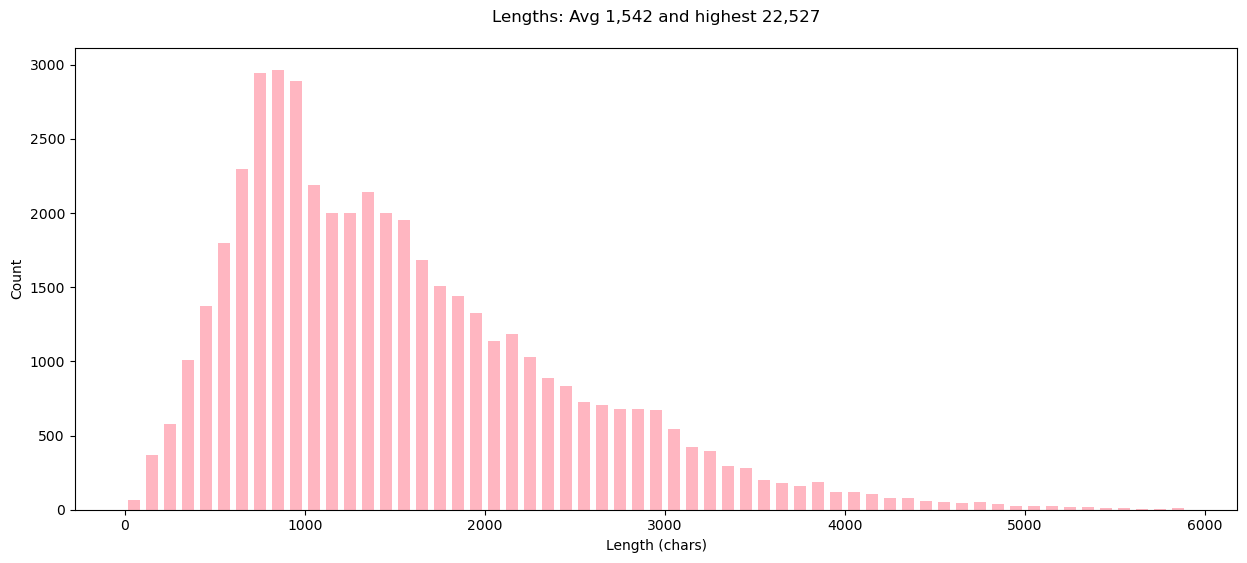

In [16]:
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightpink", bins=range(0, 6000, 100))
plt.show()

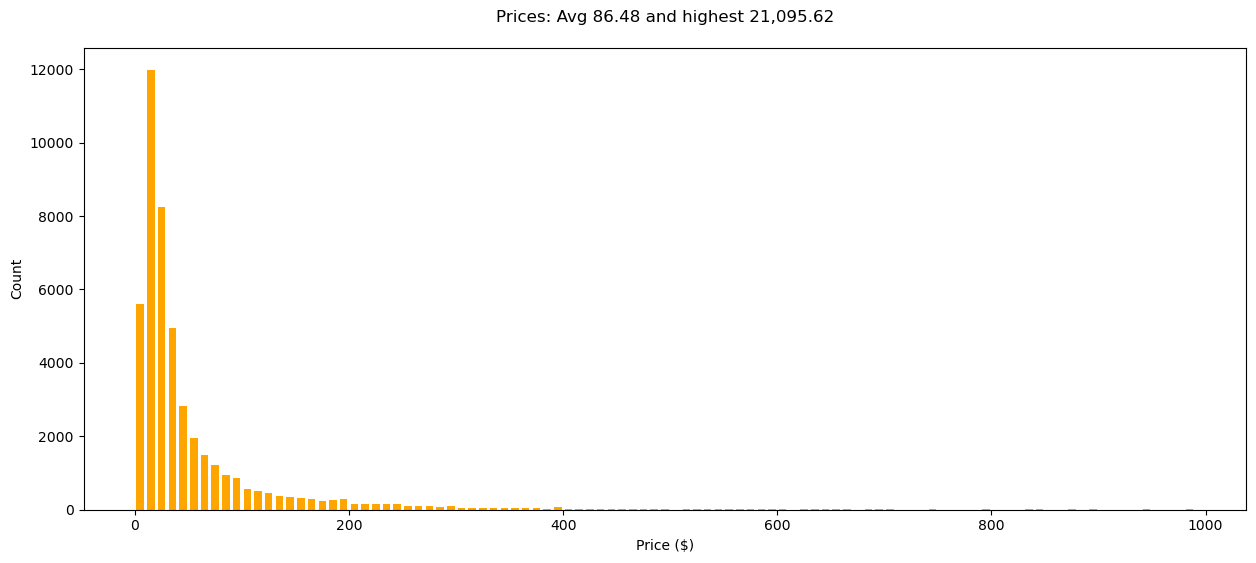

In [17]:
# Plot the distribution of prices

plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [18]:
# So what is this item??

for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 21000:
            print(datapoint['title'])
    except ValueError as e:
        pass

TurboChef BULLET Rapid Cook Electric Microwave Convection Oven


This is the closest I can find - looks like it's going at a bargain price!!

https://www.amazon.com/TurboChef-Electric-Countertop-Microwave-Convection/dp/B01D05U9NO/

## Now it's time to curate our dataset

We select items that cost between 1 and 999 USD

We will be create Item instances, which truncate the text to fit within 180 tokens using the right Tokenizer

And will create a prompt to be used during Training.

Items will be rejected if they don't have sufficient characters.

## But why 180 tokens??

A student asked me a great question - why are we truncating to 180 tokens? How did we determine that number? (Thank you Moataz A. for the excellent question).

The answer: this is an example of a "hyper-parameter". In other words, it's basically trial and error! We want a sufficiently large number of tokens so that we have enough useful information to gauge the price. But we also want to keep the number low so that we can train efficiently. You'll see this in action in Week 7.

I started with a number that seemed reasonable, and experimented with a few variations before settling on 180. If you have time, you should do the same! You might find that you can beat my results by finding a better balance. This kind of trial-and-error might sound a bit unsatisfactory, but it's a crucial part of the data science R&D process.

There's another interesting reason why we might favor a lower number of tokens in the training data. When we eventually get to use our model at inference time, we'll want to provide new products and have it estimate a price. And we'll be using short descriptions of products - like 1-2 sentences. For best performance, we should size our training data to be similar to the inputs we will provide at inference time.

## But I see in items.py it constrains inputs to 160 tokens?

Another great question from Moataz A.! The description of the products is limited to 160 tokens because we add some more text before and after the description to turn it into a prompt. That brings it to around 180 tokens in total.



In [ ]:
# Create an Item object for each with a price

items = []
for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 0:
            item = Item(datapoint, price)
            if item.include:
                items.append(item)
    except ValueError as e:
        pass

print(f"There are {len(items):,} items")
print(cont)

There are 29,032 items
46726


In [19]:
# Look at the first item

items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [20]:
# Investigate the prompt that will be used during training - the model learns to complete this

print(items[399].prompt)

How much does this cost to the nearest dollar?

Upgrade Stove Knobs Replacement 5Pcs Stainless Steel Cooker Stove Control Knob Fitable Whirlpool Gas Range Cooktop Knobs Replaces
IMPORTANT NOTE Please confirm if your knob is marked CAV1 or CAV2, if so, our knob fits your stove. If there is no CAV1 or CAV2 mark, take care to look at both sides of the knob and see if port D is oriented in the same direction as your knob. If not, it is not suitable for your stove. FIT MODELS knobs compatible with Whirlpool range knobs, Whirlpool gas stove knobs,Whirlpool range knobs, Whirlpool gas stove knobs, Whirlpool gas stove knobs, Whirlpool gas stove knobs, Whirlpool gas stove knobs

Price is €22.00


In [21]:
# Investigate the prompt that will be used during testing - the model has to complete this

print(items[100].test_prompt())

How much does this cost to the nearest dollar?

Samsung Assembly Ice Maker-Mech
This is an O.E.M. Authorized part, fits with various Samsung brand models, oem part # this product in manufactured in south Korea. This is an O.E.M. Authorized part Fits with various Samsung brand models Oem part # This is a Samsung replacement part Part Number This is an O.E.M. part Manufacturer J&J International Inc., Part Weight 1 pounds, Dimensions 18 x 12 x 6 inches, model number Is Discontinued No, Color White, Material Acrylonitrile Butadiene Styrene, Quantity 1, Certification Certified frustration-free, Included Components Refrigerator-replacement-parts, Rank Tools & Home Improvement Parts & Accessories 31211, Available April 21, 2011

Price is €


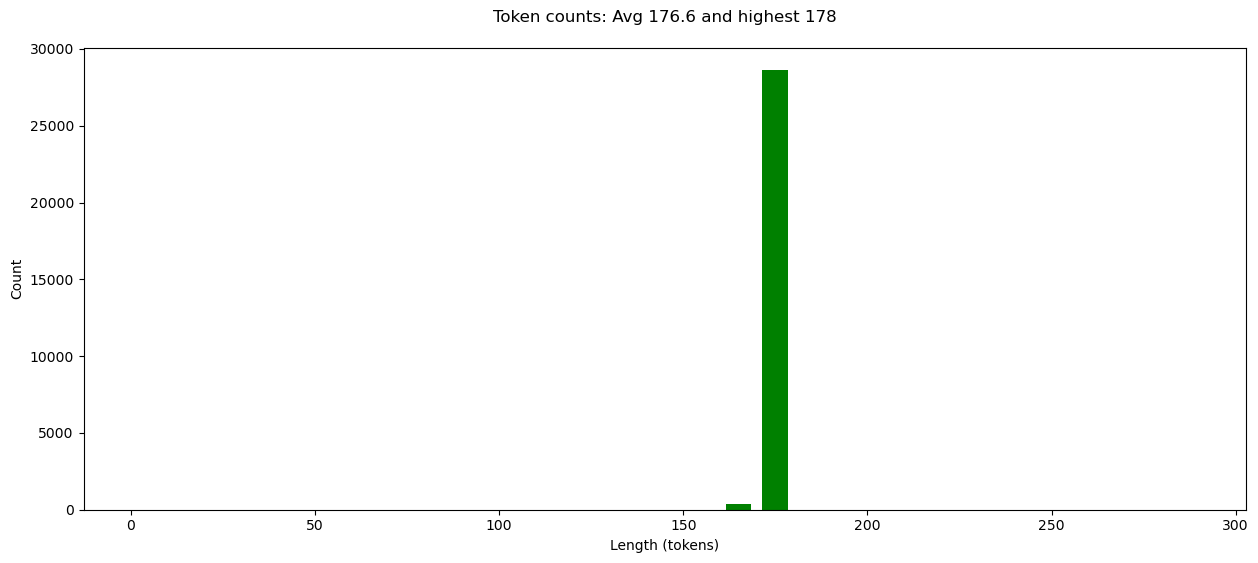

In [22]:
# Plot the distribution of token counts

tokens = [item.token_count for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="green", bins=range(0, 300, 10))
plt.show()

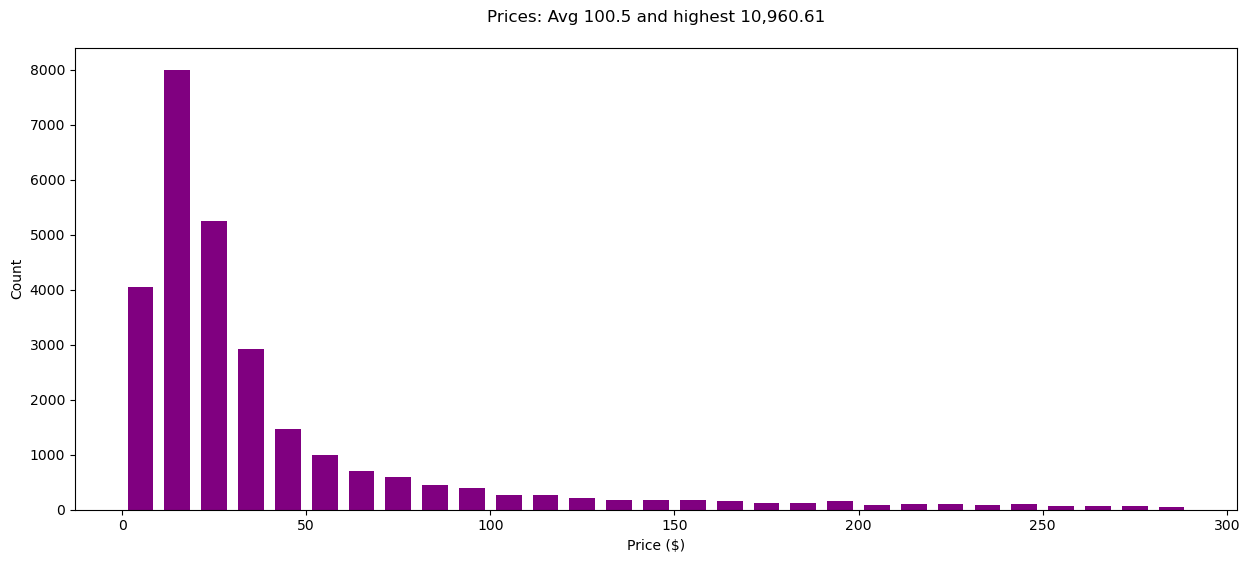

In [ ]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price (€)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="purple", bins=range(0, 300, 10))
plt.show()

## Sidenote

If you like the variety of colors that matplotlib can use in its charts, you should bookmark this:

https://matplotlib.org/stable/gallery/color/named_colors.html

## Todos for you:

- Review the Item class and check you're comfortable with it
- Examine some Item objects, look at the training prompt with `item.prompt` and test prompt with `item.test_prompt()`
- Make some more histograms to better understand the data

## Next time we will combine with many other types of product

Like Electronics and Automotive. This will give us a massive dataset, and we can then be picky about choosing a subset that will be most suitable for training.